# Bhojpuri ASR Inference Notebook

## Purpose
This notebook performs inference and evaluation on a held-out Bhojpuri test set for:
1) **zero-shot baseline comparison** across pretrained ASR models (e.g., **Whisper** vs **IndicWav2Vec**), and  
2) **adapted model variants**, where IndicWav2Vec is fine-tuned and enhanced using the adaptation pipeline described in the dissertation.

---

## What this notebook produces
Running this notebook will generate:

- Model predictions on the held-out Bhojpuri test split
- Quantitative evaluation metrics (Word Error Rate and Character Error Rate)
- Saved prediction files and evaluation outputs for analysis and comparison

All outputs are written to a configurable output directory.

---

## Experimental usage (important)
This notebook is designed to be executed **multiple times** to reproduce the experiments reported in the dissertation:

### A) Zero-shot baselines
Runs where pretrained models are evaluated **as-is** on Bhojpuri, without adaptation, to compare out-of-domain generalisation (e.g., Whisper vs IndicWav2Vec).

### B) Adapted IndicWav2Vec variants
Runs where the fine-tuned model directory is updated to load a specific experimental variant, including:
- Fine-tuning on different proportions of labelled data (e.g. one-third, two-thirds, and full dataset)
- Fine-tuning with and without acoustic data augmentation
- Tokenizer adaptation and language-model-assisted decoding (KenLM)
- Combinations of the above adaptation strategies

For each run, the model directory and decoding options are updated in the configuration section. This ensures that inference outputs remain traceable to a specific experimental condition.

---

## How to run
Run the notebook **top to bottom** without skipping cells.

The notebook follows these stages:
1. Setup (Colab environment)  
2. Setup & inference configuration  
3. Utility functions (definitions only)  
4. Test data loading  
5. Inference and decoding  
6. Evaluation and saving outputs  

---

## Assumptions and requirements

- **Model availability:**  
  Pretrained model identifiers (for zero-shot runs) and fine-tuned model directories (for adapted runs) are available and referenced via the configuration section.

- **Test data:**  
  A held-out Bhojpuri test split, disjoint from training and validation speakers, is available locally and specified via the configuration section.

- **Hardware:**  
  GPU acceleration is recommended for efficient inference. The notebook is tested on Google Colab with CUDA-enabled GPUs.

- **Software environment:**  
  Python ≥ 3.9 with PyTorch, Hugging Face Transformers, Datasets, and ASR-related dependencies installed (see Setup section).

- **Hugging Face access:**  
  If loading gated pretrained components, Hugging Face authentication may be required.  
  No access tokens are stored or hard-coded in this notebook.




## Setup note (Colab environment)

This notebook installs system-level and Python dependencies required for ASR inference,
including compiled libraries (e.g. KenLM, pyctcdecode) and version-pinned packages
(e.g. `numpy<2.0`).

As a result, **a runtime restart may be required** after the installation step.
If prompted, please restart the runtime and then re-run the notebook from the top.


In [1]:
# --- Install dependencies (Colab) ---
# This cell installs all required system and Python packages.
# If core libraries or compiled extensions are installed, a runtime restart is required.

import sys, subprocess, pkgutil, importlib.util
from pathlib import Path
from packaging import version

def run(cmd):
    print(" ".join(cmd))
    subprocess.check_call(cmd)

needs_restart = False

# -------------------------------------------------
# 1) NumPy < 2.0 workaround (critical)
# -------------------------------------------------
try:
    import numpy as np
    if version.parse(np.__version__) >= version.parse("2.0.0"):
        print(f"NumPy {np.__version__} detected (>=2.0). Downgrading...")
        run([sys.executable, "-m", "pip", "install", "-q", "numpy<2.0"])
        needs_restart = True
    else:
        print(f"NumPy OK: {np.__version__}")
except Exception:
    run([sys.executable, "-m", "pip", "install", "-q", "numpy<2.0", "packaging"])
    needs_restart = True

# -------------------------------------------------
# 2) torchcodec (CUDA-specific wheel)
# -------------------------------------------------
print("Installing torchcodec (CUDA 12.6)...")
run([
    sys.executable, "-m", "pip", "install", "-q",
    "torchcodec",
    "--index-url", "https://download.pytorch.org/whl/cu126"
])

# -------------------------------------------------
# 3) Python dependencies
# -------------------------------------------------
PYTHON_PACKAGES = [
    "datasets",
    "evaluate",
    "jiwer",
    "pyctcdecode",
    "textgrid"
]

print("Installing Python packages...")
run([sys.executable, "-m", "pip", "install", "-q"] + PYTHON_PACKAGES)

# -------------------------------------------------
# 4) KenLM (build from source)
# -------------------------------------------------

kenlm_installed = importlib.util.find_spec("kenlm") is not None

if not kenlm_installed:
    !apt-get install -y build-essential libbz2-dev liblzma-dev zlib1g-dev
    !pip install git+https://github.com/kpu/kenlm.git
    import kenlm
    needs_restart = True
else:
    print("KenLM already installed. Skipping installation.")


# -------------------------------------------------
# 5) Restart notice
# -------------------------------------------------
if needs_restart:
    print("\n===================================================")
    print("IMPORTANT: Runtime restart required.")
    print("Please restart the runtime now:")
    print("  Runtime → Restart runtime")
    print("Then rerun the notebook from the top.")
    print("===================================================\n")


NumPy OK: 1.26.4
Installing torchcodec (CUDA 12.6)...
/usr/bin/python3 -m pip install -q torchcodec --index-url https://download.pytorch.org/whl/cu126
Installing Python packages...
/usr/bin/python3 -m pip install -q datasets evaluate jiwer pyctcdecode textgrid
KenLM already installed. Skipping installation.


# 2. Setup & configuration

## Environment and versions

This notebook has been tested with the following software environment.  



In [2]:
import glob, os
import torchaudio
import librosa.display
import matplotlib.pyplot as plt
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
import torch
from jiwer import wer, cer
import pandas as pd
import seaborn as sns
import matplotlib.patches as mpatches
import numpy as np
import re
import json
#import torchaudio.sox_effects as sox
import torchaudio
from IPython.display import Audio
import soundfile as sf
import random
import textgrid
from datasets import Dataset, DatasetDict
import evaluate
from tqdm import tqdm
from transformers import pipeline
from transformers import (
AutomaticSpeechRecognitionPipeline,
WhisperTimeStampLogitsProcessor,
WhisperForConditionalGeneration,
WhisperTokenizer,
WhisperProcessor,
)
from transformers import (AutoProcessor, AutoModelForCTC, Trainer, TrainingArguments)
from transformers import DataCollatorWithPadding
from pyctcdecode import build_ctcdecoder
import importlib.util
import subprocess
import sys
inference = False
kenlm_inference = False


In [3]:
# --- Optional: Google Drive mount (Colab only) ---
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    print("Google Drive mounted.")
else:
    print("Not running in Colab; skipping Drive mount.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.


## Paths and outputs

All input and output paths are defined in one place to improve portability.


In [4]:
# -----------------------------
# Paths and outputs (Inference)
# -----------------------------
# This block centralises all key paths used by the inference notebook.
# Update these paths (especially MODEL_DIR / output variant name) for each run.

from pathlib import Path

# Toggle Google Drive usage (Colab)
USE_DRIVE = True

if USE_DRIVE:
    DRIVE_ROOT = Path("/content/drive/My Drive/ASR")
    PROJECT_DIR = DRIVE_ROOT
else:
    PROJECT_DIR = Path(".").resolve()

# ---------
# Inputs
# ---------
# Held-out test split (speaker-disjoint from training/validation)
TEST_DIR = PROJECT_DIR / "01_Data" / "lifecycle_split_LOSO" / "test"

# KenLM artifacts (only used when KenLM decoding is enabled)
KENLM_BIN_PATH = PROJECT_DIR / "bhojpuri_3gram.bin"
KENLM_ARPA_PATH = PROJECT_DIR / "bhojpuri_3gram.arpa"


# Files written by this notebook
PREDICTIONS_PATH = PROJECT_DIR / "predictions.json"
METRICS_PATH = PROJECT_DIR/ "metrics.json"

#Output
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

## Inference configuration

This section defines all inference-level flags and runtime options.
These values control model selection (zero-shot vs fine-tuned variants),
decoding behaviour (e.g. KenLM usage), and output management.

They should be modified **only here** when running inference for different
experimental conditions, to ensure that results remain reproducible and
traceable across runs.



In [5]:
# -----------------------------
# Inference configuration (edit per run)
# -----------------------------
# Use this single config block to switch between:
# (A) zero-shot baselines (Whisper / IndicWav2Vec as-trained), and
# (B) fine-tuned IndicWav2Vec variants (1/3, 2/3, full, aug, tokenizer+KenLM).

CONFIG = {

    # Name used for saving outputs (change per run to avoid overwriting)
    "variant_name": "ft_fullaugtokenkenlm",   # e.g. zeroshot_whisper, zeroshot_indic, ft_onethird, ft_twothird, ft_full, ft_fullaug, ft_fullaugtokenkenlm or none (to use stored data)


    # -------------------------
    # Model selection
    # -------------------------
    # (A) Zero-shot models (HF IDs)
    "whisper_model_id": "openai/whisper-large",     # change if you used a different Whisper size
    "indic_model_id": "ai4bharat/indicwav2vec-hindi",

    # -------------------------
    # Decoding (IndicWav2Vec only)
    # -------------------------
    # Enable KenLM shallow-fusion decoding for IndicWav2Vec outputs (optional)
    "kenlm": True,

    # Decoder hyperparameters (should match what you tuned on validation)
    "kenlm_alpha": 0.5,
    "kenlm_beta": 1.0,
    "beam_width": 5,
}



# 3. Utility functions (used throughout)

This section defines helper functions for:
- loading and filtering the dataset
- audio/text preprocessing
- augmentation operations (train-only)
- decoding and metric computation

In [6]:
def load_audio_data(data_path, sample_rate=16000):
    """
    Load an audio waveform from disk and resample it if required.

    This function standardises the sampling rate of input audio to ensure
    compatibility with downstream ASR feature extraction and inference.
    """
    waveform, sr = torchaudio.load(data_path)

    if sr != sample_rate:
        resampler = torchaudio.transforms.Resample(
            orig_freq=sr,
            new_freq=sample_rate
        )
        waveform = resampler(waveform)

    return waveform


In [7]:
def extract_transcript_from_textgrid(textgrid_path):
    """
    Extract the reference transcription from a Praat TextGrid file.

    This function concatenates non-empty interval labels to reconstruct
    the sentence-level ground-truth transcript for ASR evaluation.
    """
    tg = textgrid.TextGrid.fromFile(textgrid_path)
    tier = tg.tiers[0]

    return " ".join(
        interval.mark.strip()
        for interval in tier.intervals
        if interval.mark.strip()
    )


In [8]:
from dataclasses import dataclass
from typing import Any, Dict, List, Union
import torch


@dataclass
class DataCollatorCTCWithPadding:
    """
    Data collator for CTC-based ASR models with dynamic padding.

    This class pads input audio features and target label sequences to the
    maximum length within a batch, enabling efficient batch-wise inference
    and loss masking for CTC decoding.
    """
    processor: Any
    padding: Union[bool, str] = True

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, Any]:
        """
        Collate a batch of feature dictionaries into padded tensors.

        Padding is applied separately to input features and labels, with
        padded label positions masked using -100 to exclude them from loss
        computation.
        """
        input_features = [{"input_values": f["input_values"]} for f in features]
        label_features = [{"input_ids": f["labels"]} for f in features]

        batch = self.processor.pad(
            input_features,
            padding=self.padding,
            return_tensors="pt"
        )

        with self.processor.as_target_processor():
            labels_batch = self.processor.pad(
                label_features,
                padding=self.padding,
                return_tensors="pt"
            )

        # Mask padded label positions for CTC loss
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)
        batch["labels"] = labels

        return batch



In [9]:
def plot_log_mel(waveform, sample_rate=16000, title="Log-Mel Spectrogram"):
    """
    Visualise the log-Mel spectrogram of an audio waveform.

    This function provides a time–frequency representation commonly used
    for analysing speech characteristics and model input behaviour.
    """
    mel_spec = librosa.feature.melspectrogram(
        y=waveform.numpy(),
        sr=sample_rate,
        n_mels=80
    )
    log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(
        log_mel_spec,
        sr=sample_rate,
        x_axis="time",
        y_axis="mel"
    )
    plt.title(title)
    plt.colorbar(format="%+2.0f dB")
    plt.tight_layout()
    plt.show()



In [10]:
def infer_indicwav2vec(waveform):
    """
    Perform speech-to-text inference using the IndicWav2Vec model.

    This function encodes the input waveform, applies CTC-based decoding,
    and returns the predicted transcription.
    """
    inputs = processor(
        waveform,
        sampling_rate=16000,
        return_tensors="pt"
    )

    with torch.no_grad():
        logits = model(**inputs).logits

    predicted_ids = torch.argmax(logits, dim=-1)
    transcription = processor.batch_decode(predicted_ids)[0]

    return transcription



In [11]:
def infer_indicwav2vec_with_LM(waveform, sr=16000, beam_width=20):
    """
    Perform IndicWav2Vec inference with shallow-fusion language model decoding.

    This function applies CTC-based acoustic inference followed by
    KenLM-guided beam search to produce linguistically constrained
    transcriptions.
    """
    inputs = processor(
        waveform,
        sampling_rate=sr,
        return_tensors="pt"
    ).input_values.to(device)

    with torch.no_grad():
        logits = model(inputs).logits

    logits = logits.cpu().numpy()

    decoded = decoder.decode(logits[0])

    return decoded


In [12]:
def process_textgrid(file_path):
    """
    Parse a Praat TextGrid file and extract interval-level annotations.

    This function reads interval boundaries and associated text labels,
    returning a structured representation suitable for downstream
    transcription analysis.
    """
    try:
        with open(file_path, "r", encoding="utf-16") as f:
            lines = f.readlines()
    except UnicodeError:
        with open(file_path, "r", encoding="utf-8") as f:
            lines = f.readlines()

    intervals = []
    interval = {}

    for line in lines:
        line = line.strip()

        if line.startswith("xmin ="):
            interval["xmin"] = float(line.split("=")[1].strip())
        elif line.startswith("xmax ="):
            interval["xmax"] = float(line.split("=")[1].strip())
        elif line.startswith('text ='):
            text_match = re.search(r'text = "(.*)"', line)
            interval["text"] = text_match.group(1).strip() if text_match else ""

            if "xmin" in interval and "xmax" in interval:
                intervals.append(interval)
                interval = {}

    return intervals


In [13]:
def normalise(text: str) -> str:
    """
    Normalise text by applying training-time preprocessing rules.

    This function removes punctuation and standardises whitespace to
    ensure consistency between training and inference transcripts.
    """
    text = re.sub(r"[।|,;:?!]", " ", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [14]:
def calculate_wer_cer(refs, preds):
    """
    Compute Word Error Rate (WER) and Character Error Rate (CER).

    This function evaluates ASR output by comparing normalised predictions
    against reference transcriptions using standard error metrics.
    """
    wer_metric = evaluate.load("wer")
    cer_metric = evaluate.load("cer")

    refs = [normalise(t) for t in refs]
    preds = [normalise(t) for t in preds]

    return (
        wer_metric.compute(predictions=preds, references=refs),
        cer_metric.compute(predictions=preds, references=refs)
    )


In [15]:
def compute_log_mel(waveform, sr=16000, n_mels=80):
    """
    Compute the log-Mel spectrogram of an audio waveform.

    This function converts raw audio into a perceptually motivated
    time–frequency representation commonly used in speech analysis.
    """
    mel = librosa.feature.melspectrogram(
        y=waveform,
        sr=sr,
        n_mels=n_mels
    )

    return librosa.power_to_db(mel, ref=np.max)


In [16]:
def hindi_syllables(word):
    """
    Estimate the number of syllabic units in a Hindi word.

    This function counts Devanagari base characters while excluding
    half-letters formed using the halant (virama).
    """
    hindi_letts = (
        "कखगघङचछजझञटठडढणतथदधनपफबभमक़ख़ग़ज़ड़ढ़फ़"
        "यरलळवहशषसऱऴअआइईउऊऋॠऌॡएऐओऔॐऍऑऎऒ"
    )

    count = 0
    for i in word:
        if i in hindi_letts:
            count += 1 if word[word.index(i) - 1] != "्" else 0

    return count


In [17]:
def estimate_speaking_rate_from_transcript(transcript, duration):
    """
    Estimate speaking rate from a transcript and audio duration.

    This function computes words per second and syllables per second
    as proxy measures of speech tempo.
    """
    words = transcript.strip().split()
    syllables = sum(hindi_syllables(w) for w in words)

    words_per_sec = len(words) / duration
    syllables_per_sec = syllables / duration

    return words_per_sec, syllables_per_sec


In [18]:
def classify_gender(pitch):
    """
    Estimate speaker gender based on fundamental frequency.

    This function applies a simple pitch-based heuristic to categorise
    speakers as male or female, with undefined values marked as unknown.
    """
    if np.isnan(pitch):
        return "Unknown"
    elif pitch < 165:
        return "Male"
    else:
        return "Female"



In [19]:
def plot_spectrogram(audio_data, title="Original Audio"):
    """
    Visualise log-Mel spectrograms for a set of audio samples.

    This function plots multiple spectrograms to enable qualitative
    comparison of acoustic characteristics across audio inputs.
    """
    fig, axes = plt.subplots(2, 3, figsize=(8, 6))
    fig.suptitle(f"Log-Mel Spectrograms for {title}", fontsize=16)

    for i in range(6):
        waveform = audio_data[i]["audio"]["array"].numpy()
        spec = compute_log_mel(waveform)

        row = i // 3
        col = i % 3
        ax = axes[row][col]

        librosa.display.specshow(
            spec,
            sr=16000,
            x_axis="time",
            y_axis="mel",
            ax=ax
        )
        ax.set_title(f"Audio: {i + 1}")
        ax.label_outer()

    plt.tight_layout()
    plt.show()

In [20]:
def apply_amplitude_mask_waveform(
    waveform,
    low_freq=200,
    high_freq=400,
    sample_rate=16000
):
    """
    Apply a band-stop amplitude mask to an audio waveform.

    This function attenuates a specified frequency band to simulate
    spectral masking effects for robustness analysis.
    """
    sos = scipy.signal.butter(
        10,
        [low_freq, high_freq],
        btype="bandstop",
        fs=sample_rate,
        output="sos"
    )
    filtered_waveform = scipy.signal.sosfilt(sos, waveform)

    return filtered_waveform

In [21]:
def apply_time_mask_waveform(
    waveform,
    mask_duration_ms=150,
    sample_rate=16000
):
    """
    Apply time-domain masking to an audio waveform.

    This function zeroes a randomly selected temporal segment to simulate
    signal dropout and assess robustness to missing speech regions.
    """
    mask_duration = int((mask_duration_ms / 1000) * sample_rate)
    start = np.random.randint(0, len(waveform) - mask_duration)

    waveform[start:start + mask_duration] = 0.0

    return waveform


In [22]:
def play_audio(waveform, sample_rate=16000):
    """
    Render an audio waveform for playback within the notebook.

    """
    return Audio(waveform, rate=sample_rate)


In [23]:
def transcribe_whisper(waveform):
    """
    Perform zero-shot Hindi speech transcription using the Whisper model.

    This function applies encoder–decoder inference with a forced Hindi
    decoding prompt to generate language-specific transcriptions.
    """
    inputs = processor(
        waveform,
        sampling_rate=16000,
        return_tensors="pt"
    ).to(device)

    forced_ids = processor.get_decoder_prompt_ids(
        language="hi",
        task="transcribe"
    )

    with torch.no_grad():
        predicted_ids = model.generate(
            inputs["input_features"],
            forced_decoder_ids=forced_ids
        )

    transcription = processor.batch_decode(
        predicted_ids,
        skip_special_tokens=True
    )[0]

    return transcription


In [24]:
def plot_error_rate(wer_scores, title=None, xtitle=None, file=None):
    """
    Plot WER and CER as grouped bar charts for model or experiment comparisons.

    This function formats the input scores, orders items by WER, and produces
    a side-by-side visual comparison of WER and CER for each experiment type.
    """
    df = pd.DataFrame(wer_scores)
    df["type"] = df["type"].astype(str).str.strip()
    df = df.sort_values("WER", ascending=False).reset_index(drop=True)

    x = range(len(df))
    width = 0.35
    fig, ax = plt.subplots(figsize=(8, 5))

    bars_wer = ax.bar(
        [i - width / 2 for i in x],
        df["WER"],
        width=width,
        label="WER"
    )
    bars_cer = ax.bar(
        [i + width / 2 for i in x],
        df["CER"],
        width=width,
        label="CER"
    )

    ax.set_ylabel("Error Rate")
    ax.set_xlabel(xtitle if xtitle is not None else "")
    ax.set_title(title if title is not None else "")
    ax.set_xticks(list(x))
    ax.set_xticklabels(df["type"], rotation=45, ha="right")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.6)

    # Add headroom so bar labels do not collide with the top border
    max_err = max(df["WER"].max(), df["CER"].max())
    ax.set_ylim(0, max_err + 0.08)


    # Annotate bars with percentage values (WER/CER assumed in [0, 1]).
    for bar in list(bars_wer) + list(bars_cer):
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height * 100:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()

    if file:
        file = OUTPUT_DIR / file
        plt.savefig(file, dpi=300, bbox_inches="tight")

    plt.show()

In [25]:
def extract_vocab_from_arpa(arpa_path):
    """
    Extract unigram vocabulary from a KenLM ARPA language model file.

    This function parses the 1-gram section of an ARPA file to recover
    the vocabulary used during language model construction.
    """
    vocab = []

    try:
        with open(arpa_path, encoding="utf-8") as f:
            for line in f:
                if line.strip() == "\\1-grams:":
                    break

            for line in f:
                line = line.strip()
                if line in {"\\2-grams:", "\\end\\"} or not line:
                    break

                parts = line.split()
                if len(parts) >= 2:
                    vocab.append(parts[1])

    except FileNotFoundError:
        print(f"Error: ARPA file not found at {arpa_path}")
        return []
    except Exception as e:
        print(f"Error reading ARPA file {arpa_path}: {e}")
        return []

    if not vocab:
        print(
            f"Warning: No unigrams extracted from {arpa_path}. "
            "This may affect decoding accuracy."
        )

    with open("kenlm_vocab_from_arpa.txt", "w", encoding="utf-8") as f:
        for word in vocab:
            f.write(word + "\n")

    return vocab

---
End of utility function definitions.  
The remainder of the notebook executes the fine-tuning pipeline in a linear, top-down order.

# 4. Data loading and split verification





## Protocol clarification

Dataset splits are created **outside this notebook** (see the separate data-splitting and analysis notebook).
This notebook loads the **pre-defined test split** (i.e., held out test set) for testing and reporting the results,


The **trainval** (training and validation) is defined externally and is **not used for testing**.




In [26]:
# Construct test dataset by pairing audio files with TextGrid transcriptions
test_data = []

for fname in os.listdir(TEST_DIR):
    if fname.endswith(".wav"):
        wav_path = os.path.join(TEST_DIR, fname)
        tg_path = wav_path.replace(".wav", ".TextGrid")

        # Include sample only if aligned transcription is available
        if os.path.exists(tg_path):
            transcript = extract_transcript_from_textgrid(tg_path)
            waveform = load_audio_data(wav_path)

            test_data.append({
                "path": wav_path,
                "transcription": transcript,
                "audio": {
                    "array": waveform.squeeze(0),
                    "sampling_rate": 16000
                }
            })

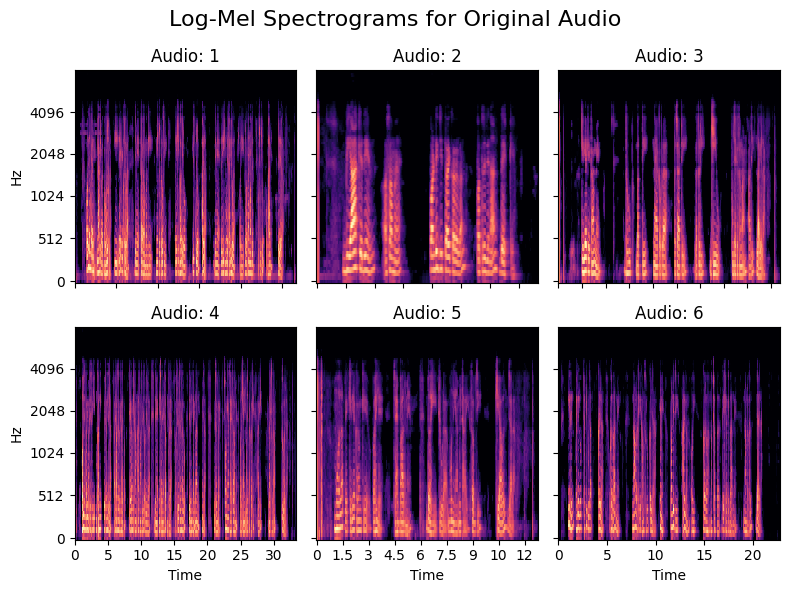

In [27]:
plot_spectrogram(test_data)

In [28]:
# Play original audio
play_audio(test_data[0]["audio"]["array"], sample_rate=16000)

# 5. Inference and decoding


In [29]:
# Load previously generated model transcriptions from disk
# ---------------------------------------------------------
# This block is used when inference is disabled for a given model configuration.
# Precomputed predictions are loaded to ensure reproducibility and to allow
# evaluation, comparison, and analysis without re-running model inference.
with open(PREDICTIONS_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

    # Zero-shot inference outputs
    trans_indic_zeroshot = data["indic_zeroshot"]
    trans_whisper_zeroshot = data["whisper_zeroshot"]

    # Fine-tuned model outputs at different training data proportions
    trans_ft_onethird = data["ft_onethird"]
    trans_ft_twothird = data["ft_twothird"]
    trans_ft_full = data["ft_full"]

    # Fine-tuned model outputs with data augmentation and language model decoding
    trans_ft_fullaug = data["ft_fullaug"]
    trans_ft_fullaugtokenkenlm = data["ft_fullaugtokenkenlm"]

    # Reference transcriptions for evaluation
    ground_truth_data_test = data["ground_truth"]


In [30]:
# Extract reference transcriptions for evaluation
# -----------------------------------------------
# Ground-truth transcripts are collected from the test dataset to serve as
# the reference labels for WER and CER computation.
ground_truth_data_test = [
    gt["transcription"] for gt in test_data
]

print(ground_truth_data_test)


['ओरी जानकारी मे बियाह के बात बहोभोज होला इ लइका के घरे होला जे मे सगा संबन्धी मित्र पडो़सी लइकी के घर के लोग इस कुल लोग आवेला जेमे लइकी के मू दिखाई भी होला अउरी लोग अपना मन से कुछू कुछू उपहार मे दे देवेला', 'बियाह के दिन अऽ समय पण्डि जी तय करेलन पतरी दिनांक देख के', 'किरिया के काम मे धुप बत्ती नया कपड़ा पचाती लकड़ी घीउ पुजा के समान आदी लागेला', 'ओरी जानकारी बाटे जैसे कि मुखाग्नी बेटा हि देला अधिकांश जगह देखल जाय तऽ किरिया करम के काम आर्य समाज से भी कर दिहल जाला जे मे तीन चार दिन मे इ सब निपट जाला अस्थी विसर्जन ला लोग तिरवेनी चाहे गंगा नदी मे लोग जाला बिसर्जन करे छौ महिना चाहे साल भर मे बरखी याने पुजा पाठ कर के आगे के घर के सुभ काम सुरु करल जाला', 'मुअला पे किरिया करम के पहिले चाहे बाद मे दहि चुड़ा बुनिया मिठाई सबजी खियावल जाला', 'इ दिन पहिले लोग छठी पुजा करेला ओकरा बाद मे नाम रखे के काम सुरु कइल जाला एमे पण्डीत जी आवेलन ओरी गरह नछतर देखेला के बाद मे नाम रखल जाय ला', 'मसान घाट पे ओरी सन्धया बेरा बितला से पहिले किरिया करम कइल जाला', 'एहमे आपने लोग जेसे के बच्चा के फुआ चाचा मामा मौसी नान

In [31]:
# Zero-shot inference using pre-trained IndicWav2Vec
# --------------------------------------------------
# This block performs direct inference using the pre-trained Hindi
# IndicWav2Vec model without any task-specific fine-tuning.
# It is executed only when the corresponding inference variant is enabled.
if CONFIG["variant_name"] == "zeroshot_indic":
    processor = Wav2Vec2Processor.from_pretrained(
        "ai4bharat/indicwav2vec-hindi"
    )
    model = Wav2Vec2ForCTC.from_pretrained(
        "ai4bharat/indicwav2vec-hindi"
    )

    trans_indic_zeroshot = []

    for audio in test_data:
        transcription = infer_indicwav2vec(
            audio["audio"]["array"]
        )
        trans_indic_zeroshot.append(transcription)



In [32]:
wer_scores = []
zero_shot_scores = []

# Calculate WER
overall_wer, overall_cer = calculate_wer_cer(ground_truth_data_test, trans_indic_zeroshot)
zero_shot_scores.append({"type": "IndicWav2Vec", "WER": overall_wer, "CER": overall_cer })
wer_scores.append({"type": "Zero Shot", "WER": overall_wer, "CER": overall_cer })

print(f"Overall Word Error Rate (WER): {overall_wer:.2%}")
print(f"Overall Character Error Rate (CER): {overall_cer:.2%}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Overall Word Error Rate (WER): 62.95%
Overall Character Error Rate (CER): 20.52%


In [33]:

# Zero-shot inference using the Whisper model
# ------------------------------------------
# This block performs encoder–decoder ASR inference using a pre-trained
# Whisper model without task-specific fine-tuning. Language-specific
# decoding is enforced during generation.
if CONFIG["variant_name"] == "zeroshot_whisper":

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    model_name = CONFIG["whisper_model_id"]
    processor = WhisperProcessor.from_pretrained(model_name)

    model = WhisperForConditionalGeneration.from_pretrained(
        model_name
    ).to(device)
    model.eval()

    trans_whisper_zeroshot = []

    for audio in test_data:
        transcription = transcribe_whisper(
            audio["audio"]["array"]
        )
        trans_whisper_zeroshot.append(transcription)

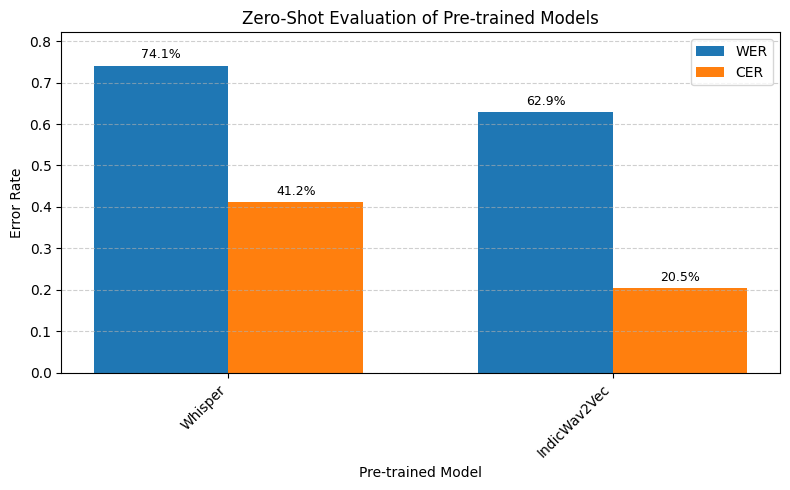

In [34]:
# Calculate WER
overall_wer, overall_cer = calculate_wer_cer(ground_truth_data_test, trans_whisper_zeroshot)
zero_shot_scores.append({"type": "Whisper", "WER": overall_wer, "CER": overall_cer })
#plot_error_rate(zero_shot_scores, "yes")
plot_error_rate(zero_shot_scores, title = "Zero-Shot Evaluation of Pre-trained Models", xtitle = "Pre-trained Model", file= "zeroshot.png")


In [35]:
# Inference using IndicWav2Vec fine-tuned on one-third of the training data
# -----------------------------------------------------------------------
# This block evaluates a partially fine-tuned model to assess performance
# gains as a function of available labelled data.
if CONFIG["variant_name"] == "ft_onethird":
    path = r"/content/drive/My Drive/ASR/ft_onethird"

    processor = Wav2Vec2Processor.from_pretrained(path)
    model = Wav2Vec2ForCTC.from_pretrained(path)

    trans_ft_onethird = []

    for audio in test_data:
        transcription = infer_indicwav2vec(
            audio["audio"]["array"]
        )
        trans_ft_onethird.append(transcription)

# Compute evaluation metrics for the one-third fine-tuned model
overall_wer, overall_cer = calculate_wer_cer(
    ground_truth_data_test,
    trans_ft_onethird
)
wer_scores.append({
    "type": "1/3rd data",
    "WER": overall_wer,
    "CER": overall_cer
})

In [36]:
# Inference using IndicWav2Vec fine-tuned on two-thirds of the training data
# ------------------------------------------------------------------------
# This block evaluates a model fine-tuned with increased labelled data
# to analyse the relationship between data volume and ASR performance.
if CONFIG["variant_name"] == "ft_twothird":
    path = r"/content/drive/My Drive/ASR/ft_twothird"

    processor = Wav2Vec2Processor.from_pretrained(path)
    model = Wav2Vec2ForCTC.from_pretrained(path)

    trans_ft_twothird = []

    for audio in test_data:
        transcription = infer_indicwav2vec(
            audio["audio"]["array"]
        )
        trans_ft_twothird.append(transcription)


In [37]:
# Calculate WER
overall_wer, overall_cer = calculate_wer_cer(ground_truth_data_test, trans_ft_twothird)
wer_scores.append({"type": "2/3rd data", "WER": overall_wer, "CER": overall_cer })

In [38]:
# plot_Error_Rates(wer_scores)

In [39]:
# Inference using IndicWav2Vec fine-tuned on the full training dataset
# ------------------------------------------------------------------
# This block evaluates the model fine-tuned using all available
# labelled data, providing an upper-bound performance reference.
if CONFIG["variant_name"] == "ft_full":
    path = r"/content/drive/My Drive/ASR/ft_full"

    processor = Wav2Vec2Processor.from_pretrained(path)
    model = Wav2Vec2ForCTC.from_pretrained(path)

    trans_ft_full = []

    for audio in test_data:
        transcription = infer_indicwav2vec(
            audio["audio"]["array"]
        )
        trans_ft_full.append(transcription)

In [40]:
# Calculate WER
overall_wer, overall_cer = calculate_wer_cer(ground_truth_data_test, trans_ft_full)
wer_scores.append({"type": "Full data", "WER": overall_wer, "CER": overall_cer })

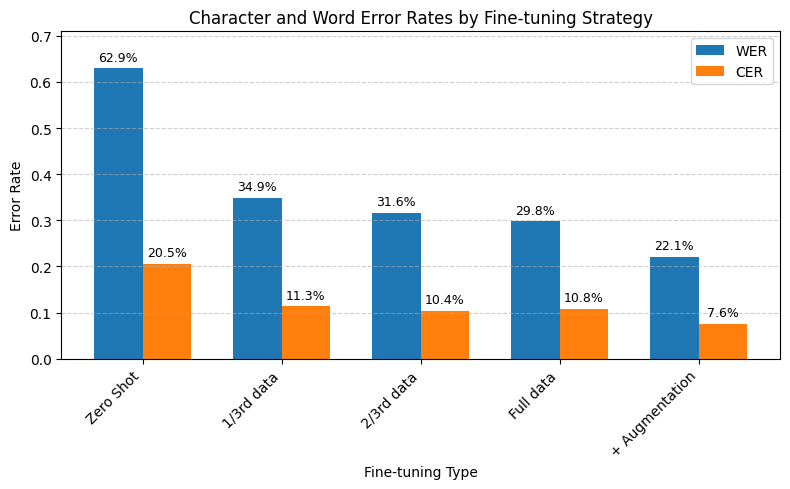

In [41]:
# Inference using the fully fine-tuned model with augmentation and KenLM decoding
# ----------------------------------------------------------------------------
# This block evaluates the best-performing configuration: full-data fine-tuning
# with augmentation, followed by shallow-fusion decoding using a corpus-trained
# KenLM language model to enforce linguistic constraints at inference time.
if CONFIG["variant_name"] == "ft_fullaug":

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    model_path = r"/content/drive/My Drive/ASR/ft_fullaug"
    kenlm_path = KENLM_BIN_PATH
    arpa_path = KENLM_ARPA_PATH

    processor = Wav2Vec2Processor.from_pretrained(model_path)
    model = Wav2Vec2ForCTC.from_pretrained(model_path).to(device).eval()

    # Build a CTC beam-search decoder with KenLM shallow fusion (initialised once)
    labels = [
        token for token, _ in sorted(
            processor.tokenizer.get_vocab().items(),
            key=lambda kv: kv[1]
        )
    ]

    # Restrict decoding to LM vocabulary (unigrams) extracted from the ARPA file
    unigrams = extract_vocab_from_arpa(arpa_path)

    decoder = build_ctcdecoder(
        labels=labels,
        kenlm_model_path=kenlm_path,
        unigrams=unigrams,
        alpha=CONFIG["kenlm_alpha"],   # LM weight (tuned on dev set)
        beta=CONFIG["kenlm_beta"]      # word insertion penalty (tuned on dev set)
    )

    trans_ft_fullaug = []

    for audio in test_data:
        transcription = infer_indicwav2vec_with_LM(
            audio["audio"]["array"]
        )
        trans_ft_fullaug.append(transcription)

# Evaluate ASR output against ground truth using standard error metrics
overall_wer, overall_cer = calculate_wer_cer(
    ground_truth_data_test,
    trans_ft_fullaug
)
wer_scores.append({
    "type": "+ Augmentation",
    "WER": overall_wer,
    "CER": overall_cer
})

plot_error_rate(
    wer_scores,
    title="Character and Word Error Rates by Fine-tuning Strategy",
    xtitle="Fine-tuning Type",
    file="fullauglmcust.png"
)

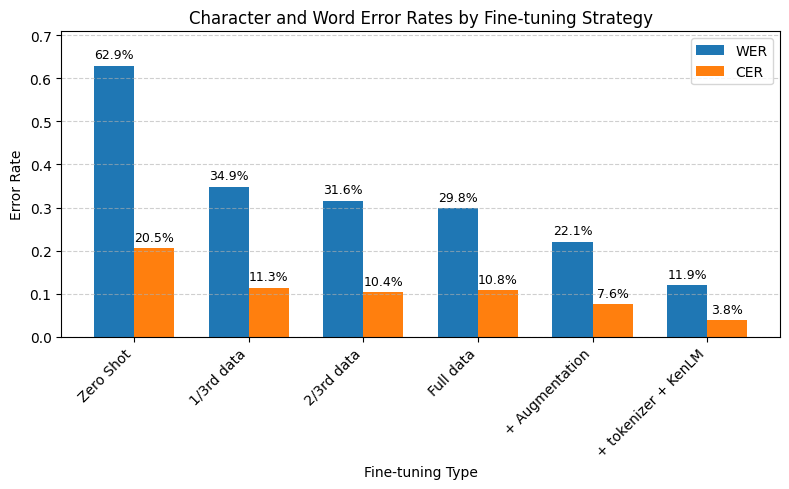

In [42]:
# Inference using the fully fine-tuned model with tokenizer adaptation and KenLM
# -----------------------------------------------------------------------------
# This block evaluates the most constrained configuration, combining full-data
# fine-tuning, tokenizer adaptation, and shallow-fusion decoding with a
# corpus-trained KenLM language model.
if CONFIG["variant_name"] == "ft_fullaugtokenkenlm":

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    model_path = r"/content/drive/My Drive/ASR/ft_fullaugtokenkenlm"
    kenlm_path = str(KENLM_BIN_PATH)
    arpa_path = str(KENLM_ARPA_PATH)

    processor = Wav2Vec2Processor.from_pretrained(model_path)
    model = Wav2Vec2ForCTC.from_pretrained(model_path).to(device).eval()

    # Build a CTC beam-search decoder with KenLM shallow fusion
    # Token labels reflect the adapted tokenizer used during fine-tuning
    labels = [
        token for token, _ in sorted(
            processor.tokenizer.get_vocab().items(),
            key=lambda kv: kv[1]
        )
    ]

    # Extract unigram vocabulary from the ARPA language model
    unigrams = extract_vocab_from_arpa(arpa_path)

    decoder = build_ctcdecoder(
        labels=labels,
        kenlm_model_path=kenlm_path,
        unigrams=unigrams,
        alpha=CONFIG["kenlm_alpha"],   # LM weight (tuned on dev set)
        beta=CONFIG["kenlm_beta"]      # word insertion penalty (tuned on dev set)
    )

    trans_ft_fullaugtokenkenlm = []

    for audio in test_data:
        transcription = infer_indicwav2vec_with_LM(
            audio["audio"]["array"]
        )
        trans_ft_fullaugtokenkenlm.append(transcription)

# Evaluate predictions against ground truth
overall_wer, overall_cer = calculate_wer_cer(
    ground_truth_data_test,
    trans_ft_fullaugtokenkenlm
)
wer_scores.append({
    "type": "+ tokenizer + KenLM",
    "WER": overall_wer,
    "CER": overall_cer
})

plot_error_rate(
    wer_scores,
    title="Character and Word Error Rates by Fine-tuning Strategy",
    xtitle="Fine-tuning Type",
    file="speclmcust.png"
)


In [43]:
# Persist model predictions for reproducibility and offline evaluation
# --------------------------------------------------------------------
# All transcriptions produced across different inference configurations
# are saved to disk. This enables result reuse, fair comparison across
# models, and evaluation without re-running inference.
import json

with open(PREDICTIONS_PATH, "w", encoding="utf-8") as f:
    json.dump(
        {
            "indic_zeroshot": trans_indic_zeroshot,
            "whisper_zeroshot": trans_whisper_zeroshot,
            "ft_onethird": trans_ft_onethird,
            "ft_twothird": trans_ft_twothird,
            "ft_full": trans_ft_full,
            "ft_fullaugtokenkenlm": trans_ft_fullaugtokenkenlm,
            "ft_fullaug": trans_ft_fullaug,
            "ground_truth": ground_truth_data_test
        },
        f,
        ensure_ascii=False,
        indent=4
    )

In [44]:
# Persist evaluation metrics for reproducibility and reporting
# ------------------------------------------------------------
# Aggregate WER and CER scores across all inference variants
# are saved to disk to support result verification and reuse
# in figures, tables, and further analysis.
with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(
        {
            "wer_scores": wer_scores
        },
        f,
        ensure_ascii=False,
        indent=4
    )